# Cross-Attention Weight Analysis

The cross-attention module produces a `(B, num_queries=2, V)` attention tensor per sample. Each row of this tensor is a softmax distribution over views, showing how much each task-query attended to each camera view.

This notebook extracts these weights from the best cross-attention checkpoint on the test set and visualizes:

1. **Per-action-class attention patterns.** Do different foul types rely on different views?
2. **Per-query specialization.** Do the two learnable query tokens attend to different views (i.e. has the model learned task-specific view selection)?
3. **Attention entropy.** Does the model make sharp decisions (focused on few views) or soft decisions (evenly spread)?

Even if the cross-attention model did not outperform simpler baselines, these visualizations show what the model learned and whether its attention behavior is interpretable.

In [ ]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

with open('../cross_attention_weights.json') as f:
    entries = json.load(f)

print(f'Loaded {len(entries)} test samples')
print('Example entry:', {k: v for k, v in entries[0].items() if k != 'attention'})
print('Attention shape:', np.array(entries[0]['attention']).shape)

Loaded 251 test samples
Example entry: {'action_id': '0', 'gt_action_class': 'Tackling', 'gt_offence': 'Offence', 'gt_severity': '1.0', 'num_views': 2, 'pred_action_idx': 1, 'pred_os_idx': 1}
Attention shape: (2, 2)


## Distribution of View Counts

How many views does each test sample have? This affects how we can aggregate attention patterns.

2    174
3     65
4     12
Name: count, dtype: int64


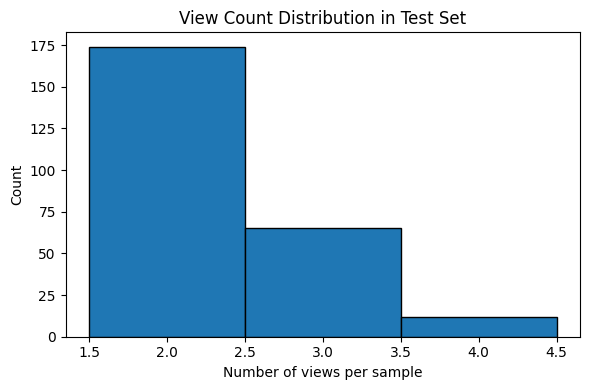

In [6]:
view_counts = [e['num_views'] for e in entries]
print(pd.Series(view_counts).value_counts().sort_index())

fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(view_counts, bins=np.arange(min(view_counts) - 0.5, max(view_counts) + 1.5), edgecolor='black')
ax.set_xlabel('Number of views per sample')
ax.set_ylabel('Count')
ax.set_title('View Count Distribution in Test Set')
plt.tight_layout()
plt.show()

## Attention Entropy per Query

Entropy measures how spread-out the attention distribution is. Low entropy (close to 0) means the query focuses on one view; high entropy (close to `log(V)`) means uniform attention across all views.

If the model simply falls back to uniform attention (equivalent to mean pooling), the entropy will be near `log(V)`. If it makes sharp decisions, entropy will be much lower.

In [7]:
def entropy(p):
    p = np.asarray(p)
    p = p[p > 1e-10]
    return -np.sum(p * np.log(p))

rows = []
for e in entries:
    attn = np.array(e['attention'])  # (num_queries, V)
    V = attn.shape[1]
    max_entropy = np.log(V)
    for q in range(attn.shape[0]):
        ent = entropy(attn[q])
        rows.append({
            'action_id': e['action_id'],
            'action_class': e['gt_action_class'],
            'query': q,
            'num_views': V,
            'entropy': ent,
            'entropy_ratio': ent / max_entropy if max_entropy > 0 else 0,
        })

ent_df = pd.DataFrame(rows)
print('Mean entropy ratio (0 = fully focused, 1 = uniform):')
print(ent_df.groupby('query')['entropy_ratio'].describe().round(3))

Mean entropy ratio (0 = fully focused, 1 = uniform):
       count   mean    std    min    25%    50%    75%  max
query                                                      
0      251.0  0.988  0.015  0.899  0.983  0.993  0.997  1.0
1      251.0  0.980  0.024  0.847  0.973  0.986  0.996  1.0


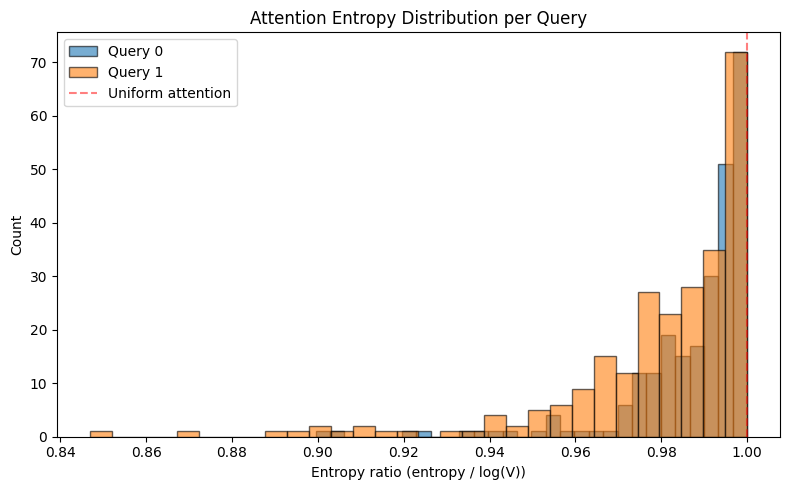

In [8]:
fig, ax = plt.subplots(figsize=(8, 5))
for q in [0, 1]:
    vals = ent_df[ent_df['query'] == q]['entropy_ratio']
    ax.hist(vals, bins=30, alpha=0.6, label=f'Query {q}', edgecolor='black')
ax.axvline(x=1.0, color='red', linestyle='--', alpha=0.5, label='Uniform attention')
ax.set_xlabel('Entropy ratio (entropy / log(V))')
ax.set_ylabel('Count')
ax.set_title('Attention Entropy Distribution per Query')
ax.legend()
plt.tight_layout()
plt.savefig('plots/plot_attention_entropy.png', dpi=150)
plt.show()

### Attention is essentially uniform (degenerate)

The entropy ratios are 0.988 for Query 0 and 0.980 for Query 1, with nearly all samples clustered above 0.96. A ratio of 1.0 means perfectly uniform attention across views. The cross-attention module learned to divide attention almost equally across all views for nearly every sample. This is functionally equivalent to **mean pooling**.

## Mean Attention per View Position

Are certain view positions (e.g. view 0, which is often the main camera) more attended to than others? This restricts analysis to samples with exactly 4 views (the most common count) for fair comparison.

Analyzing samples with exactly V=2 views (174 samples)


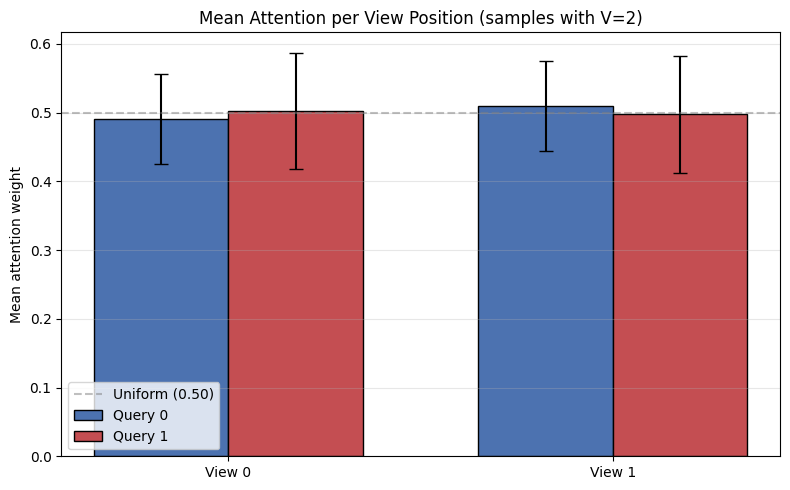

In [9]:
target_V = pd.Series(view_counts).value_counts().idxmax()
print(f'Analyzing samples with exactly V={target_V} views ({sum(1 for e in entries if e["num_views"] == target_V)} samples)')

# Stack attention weights from samples with V=target_V
attn_stack = np.array([
    e['attention'] for e in entries if e['num_views'] == target_V
])  # (N, num_queries, V)

mean_attn = attn_stack.mean(axis=0)  # (num_queries, V)
std_attn = attn_stack.std(axis=0)

fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(target_V)
width = 0.35

ax.bar(x - width/2, mean_attn[0], width, yerr=std_attn[0], capsize=5,
       label='Query 0', color='#4C72B0', edgecolor='black')
ax.bar(x + width/2, mean_attn[1], width, yerr=std_attn[1], capsize=5,
       label='Query 1', color='#C44E52', edgecolor='black')
ax.axhline(y=1/target_V, color='gray', linestyle='--', alpha=0.5, label=f'Uniform ({1/target_V:.2f})')
ax.set_xticks(x)
ax.set_xticklabels([f'View {i}' for i in range(target_V)])
ax.set_ylabel('Mean attention weight')
ax.set_title(f'Mean Attention per View Position (samples with V={target_V})')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('plots/plot_attention_per_view.png', dpi=150)
plt.show()

### Per-view-position bias is negligible

For samples with V=2, mean attention is between 0.49 and 0.51 across both views and both queries, with large error bars (std roughly 0.07) spanning both sides of uniform. There is no systematic preference for any view position.

## Per-Class Attention Heatmap

For each action class and each query, the mean attention weight placed on each view position. If different action types attend to different views, we would see distinct rows in the heatmap. If all rows look similar, the model learned a generic attention pattern regardless of the action class.

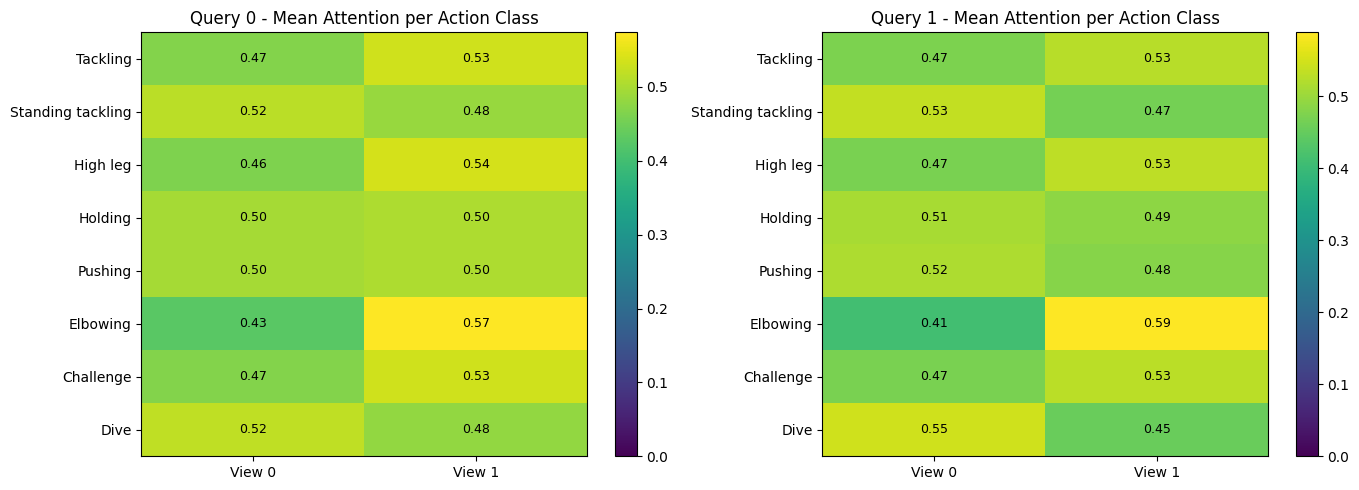

In [10]:
action_classes = ['Tackling', 'Standing tackling', 'High leg', 'Holding',
                  'Pushing', 'Elbowing', 'Challenge', 'Dive']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for q, ax in zip([0, 1], axes):
    heatmap = np.zeros((len(action_classes), target_V))
    for i, cls in enumerate(action_classes):
        cls_entries = [e for e in entries
                       if e['gt_action_class'] == cls and e['num_views'] == target_V]
        if not cls_entries:
            continue
        attns = np.array([e['attention'][q] for e in cls_entries])
        heatmap[i] = attns.mean(axis=0)

    im = ax.imshow(heatmap, cmap='viridis', aspect='auto', vmin=0, vmax=heatmap.max())
    ax.set_xticks(range(target_V))
    ax.set_xticklabels([f'View {i}' for i in range(target_V)])
    ax.set_yticks(range(len(action_classes)))
    ax.set_yticklabels(action_classes)
    ax.set_title(f'Query {q} - Mean Attention per Action Class')

    for i in range(len(action_classes)):
        for j in range(target_V):
            txt_color = 'white' if heatmap[i, j] < heatmap.max() * 0.6 else 'black'
            ax.text(j, i, f'{heatmap[i, j]:.2f}', ha='center', va='center',
                    color=txt_color, fontsize=9)

    plt.colorbar(im, ax=ax)

plt.tight_layout()
plt.savefig('plots/plot_attention_heatmap.png', dpi=150)
plt.show()

### Interpretation: Action classes have no distinct attention fingerprint

The per-class heatmap shows attention values between 0.41 and 0.59 for all 8 action classes. Every row looks nearly identical, clustered around the uniform value of 0.5. There is no class-specific view selection. For example, Elbowing has a small bias toward View 1 (0.57 vs 0.43), and Dive has a slight bias toward View 0 (0.52 vs 0.48), but these deviations are within the natural noise range seen across classes and are not actionable patterns.

## Query Specialization Check

Do the two queries attend to the same views (redundant) or different ones (specialized)? Low mean squared difference means the queries produce similar attention patterns.

Mean L1 distance between queries: 0.021
Std: 0.013
(0 = identical attention, 1 = completely disjoint)


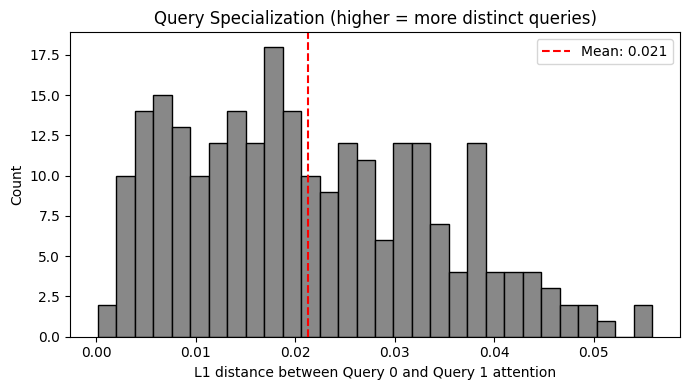

In [11]:
diffs = []
for e in entries:
    attn = np.array(e['attention'])
    # L1 difference between the two queries' attention distributions
    diffs.append(np.abs(attn[0] - attn[1]).sum() / 2)  # divide by 2 for normalized [0,1]

print(f'Mean L1 distance between queries: {np.mean(diffs):.3f}')
print(f'Std: {np.std(diffs):.3f}')
print('(0 = identical attention, 1 = completely disjoint)')

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(diffs, bins=30, edgecolor='black', color='#888888')
ax.axvline(x=np.mean(diffs), color='red', linestyle='--', label=f'Mean: {np.mean(diffs):.3f}')
ax.set_xlabel('L1 distance between Query 0 and Query 1 attention')
ax.set_ylabel('Count')
ax.set_title('Query Specialization (higher = more distinct queries)')
ax.legend()
plt.tight_layout()
plt.show()

### The two task-query tokens learned the same thing

The mean L1 distance between Query 0's and Query 1's attention distributions is 0.021 on a scale where 0 means identical and 1 means disjoint. Both queries converged to produce essentially the same attention pattern. The model did not learn to use the two queries for different purposes. One of them is redundant.

## Conclusion

Cross-attention had the opportunity to learn view-specific, class-specific, or task-specific attention patterns, and across 251 test samples it learned **none of them**. The module collapsed to near-uniform averaging. This explains the quantitative result: cross-attention's ~1M parameters did not produce a useful inductive bias because they effectively reproduced what mean pooling does for free. The extra parameters acted as noise in the optimization, which is consistent with cross-attention's higher standard deviation across seeds and slightly lower mean performance.

This is a strong finding for the thesis discussion because it gives a mechanistic explanation for the null result. The aggregation module did not fail because cross-attention is the wrong architecture in principle. It failed because the training data (~2300 samples with only 2 views per training sample) did not provide enough signal for the module to learn anything beyond uniform averaging. A practitioner working on a larger multi-view dataset might still benefit from cross-attention, but on SoccerNet-MVFoul at this scale, the extra capacity is wasted.